In [1]:
"""
MNIST Action Transformer Network

This module implements a neural network that takes an MNIST digit image and a one-hot encoded action
in the range [-max_move, max_move] and outputs an MNIST digit from the class corresponding to 
input digit + action.

The network architecture:
1. Encoder: CNN to process MNIST image (28x28) -> feature vector
2. Action fusion: Concatenate image features with one-hot action vector
3. Decoder: MLP to generate output MNIST image (28x28)

Training data: For each sample, we take an MNIST image, apply a random action, and the target
is a random MNIST image from the class (original_digit + action) % 10.
"""
from utils import calc_NC1
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import random
from tqdm import tqdm
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")


def get_r_2(X, y):
    model = LinearRegression().fit(X, y)
    y_pred = model.predict(X)
    return r2_score(y, y_pred)


In [2]:
retrain_mnist_classifier = False
import os

# Improved classifier: use a CNN for MNIST, which can easily reach >99.7% accuracy.
class MNISTCNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  # 28x28 -> 28x28
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), # 28x28 -> 28x28
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                 # 28x28 -> 14x14
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, 3, padding=1), # 14x14 -> 14x14
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 14x14 -> 7x7
            nn.Dropout(0.25),
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(128*7*7, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        # x: (batch, 1, 28, 28)
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

def train_classifier(epochs=15, device="cuda"):
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    train_ds = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

    clf = MNISTCNNClassifier().to(device)
    opt = torch.optim.Adam(clf.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=7, gamma=0.5)

    for epoch in range(epochs):
        clf.train()
        total = 0
        correct = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = clf(x)
            loss = F.cross_entropy(logits, y)

            opt.zero_grad()
            loss.backward()
            opt.step()

            total += y.size(0)
            correct += (logits.argmax(1) == y).sum().item()

        acc = correct / total * 100
        print(f"Epoch {epoch+1}, Acc: {acc:.2f}%")
        scheduler.step()

    # Optionally, evaluate on the training set for 100% accuracy
    clf.eval()
    with torch.no_grad():
        total = 0
        correct = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits = clf(x)
            total += y.size(0)
            correct += (logits.argmax(1) == y).sum().item()
        acc = correct / total * 100
        print(f"Final training accuracy: {acc:.2f}%")
    return clf

device = "cuda"

if not os.path.exists("./saved_models/mnist_classifier.pth") or retrain_mnist_classifier:
    clf = train_classifier(epochs=15, device=device)
    torch.save(clf.state_dict(), "./saved_models/mnist_classifier.pth")


In [ ]:
class MNISTActionDataset(Dataset):
    """
    Custom dataset for MNIST with actions.
    
    For each sample:
    - Input: MNIST image + one-hot encoded action
    - Target: Random MNIST image from class (original_digit + action) % 10
    """
    
    def __init__(self, mnist_dataset, max_move=2, transform=None, cyclic=False, sample_max_move=None):
        self.mnist = mnist_dataset
        self.max_move = max_move
        self.action_space = 2 * max_move + 1  # [-max_move, ..., max_move]
        self.transform = transform
        self.cyclic = cyclic
        self.sample_max_move = sample_max_move if sample_max_move is not None else max_move
        
        # Build index for each digit class for fast sampling
        self.class_to_indices = {i: [] for i in range(10)}
        for idx, (_, label) in enumerate(self.mnist):
            self.class_to_indices[label].append(idx)
    
    def __len__(self):
        return len(self.mnist)
    
    def __getitem__(self, idx):
        # Get original image and label
        img, label = self.mnist[idx]
        
        # Sample random action in [-max_move, max_move]
        # Compute target class: (label + action) % 10
        action = random.randint(-self.sample_max_move, self.sample_max_move)
        target_class = (label + action) % 10 if self.cyclic else label + action # 
        while target_class < 0 or target_class > 9:
            action = random.randint(-self.max_move, self.max_move)
            target_class = (label + action) % 10 if self.cyclic else label + action # 
        
        # One-hot encode action
        action_onehot = torch.zeros(self.action_space)
        action_onehot[action + self.max_move] = 1.0
        
        
        # Sample a random image from the target class
        target_indices = self.class_to_indices[target_class]
        target_idx = random.choice(target_indices)
        target_img, _ = self.mnist[target_idx]
        
        # Apply transforms if provided
        if self.transform:
            img = self.transform(img)
            target_img = self.transform(target_img)
        
        return {
            'input_img': img,
            'action': action_onehot,
            'target_img': target_img,
            'original_label': label,
            'action_value': action,
            'target_label': target_class
        }


class MNISTActionTransformer(nn.Module):
    """
    Neural network that transforms MNIST digits based on actions.
    
    Architecture:
    1. Image Encoder: CNN to extract features from MNIST image
    2. Action Fusion: Concatenate image features with action vector
    3. Image Decoder: MLP to generate output MNIST image
    """
    
    def __init__(self, max_move=2, hidden_dim=512, latent_dim=256, n_layers_fusion=1):
        super(MNISTActionTransformer, self).__init__()
        
        self.max_move = max_move
        self.action_space = 2 * max_move + 1
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.n_layers_fusion = n_layers_fusion
        
        # Image Encoder: CNN to extract features from 28x28 MNIST image
        self.image_encoder = nn.Sequential(
            # 28x28 -> 14x14
            nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            
            # 14x14 -> 7x7
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            # 7x7 -> 4x4 (using kernel_size=3, stride=2, padding=1)
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            # Flatten: 128 * 4 * 4 = 2048
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, self.latent_dim),
            nn.ReLU(inplace=True)
        )
        
        # Action fusion: Combine image features with action
        fusion_layers = []
        # First layer: input is latent_dim + action_space
        fusion_layers.append(nn.Linear(self.latent_dim + self.action_space, self.hidden_dim))
        fusion_layers.append(nn.ReLU(inplace=True))
        fusion_layers.append(nn.Dropout(0.2))
        # Add (n_layers_fusion - 1) hidden layers
        for _ in range(self.n_layers_fusion - 1):
            fusion_layers.append(nn.Linear(self.hidden_dim, self.hidden_dim))
            fusion_layers.append(nn.ReLU(inplace=True))
            fusion_layers.append(nn.Dropout(0.2))
        self.fusion_layer = nn.Sequential(*fusion_layers)
        
        # Image Decoder: Generate output MNIST image
        self.image_decoder = nn.Sequential(
            nn.Linear(self.hidden_dim, 128 * 7 * 7),
            nn.ReLU(inplace=True),
            nn.Unflatten(1, (128, 7, 7)),
            
            # 7x7 -> 14x14
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            # 14x14 -> 28x28
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            
            # Final layer to 1 channel
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=1, padding=1),
            nn.Sigmoid()  # Output in [0, 1]
        )
    
    def forward(self, input_img, action):
        # Encode input image
        img_features = self.image_encoder(input_img)
        
        # Fuse image features with action
        fused_features = torch.cat([img_features, action], dim=1)
        fused_features = self.fusion_layer(fused_features)
        
        # Decode to output image
        output_img = self.image_decoder(fused_features)
        
        return output_img

    def get_hidden(self, input_img, action):
        """
        Returns the hidden (fused) features before decoding.
        """
        img_features = self.image_encoder(input_img)
        fused_features = torch.cat([img_features, action], dim=1)
        fused_features = self.fusion_layer(fused_features)
        return fused_features


def train_model(model, train_loader, val_loader, device, epochs=50, lr=1e-3, save_dir='./checkpoints', lambda_clf=1):
    """
    Train the MNIST Action Transformer model.
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    criterion = nn.MSELoss()
    
    # Create save directory
    os.makedirs(save_dir, exist_ok=True)
    
    #########################################################
    clf = MNISTCNNClassifier().to(device)
    clf.load_state_dict(torch.load("./saved_models/mnist_classifier.pth"))
    clf.eval()
    for p in clf.parameters():
        p.requires_grad = False
    #########################################################
    
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    avg_train_loss = 0.0
    avg_val_loss = 0.0
    for epoch in tqdm(range(epochs), desc=f'Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}'):
        # Training phase
        model.train()
        train_loss = 0.0
        train_batches = 0
        
        for batch in train_loader:
            input_img = batch['input_img'].to(device)
            action = batch['action'].to(device)
            target_img = batch['target_img'].to(device)
            target_digit = batch['target_label'].to(device)
            
            optimizer.zero_grad()
            output_img = model(input_img, action)
            loss = criterion(output_img, target_img)

            
            #########################################################
            # Classifier loss on generated image
            output_img_reshaped = output_img.view(-1, 1, 28, 28)  # reshape to (batch, channels, H, W)
            class_logits = clf(output_img)  # freeze classifier
            clf_loss = F.cross_entropy(class_logits, target_digit)
            loss += lambda_clf * clf_loss
            #########################################################


            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_batches += 1
        
        avg_train_loss = train_loss / train_batches
        train_losses.append(avg_train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        val_batches = 0
        
        with torch.no_grad():
            for batch in val_loader:
                input_img = batch['input_img'].to(device)
                action = batch['action'].to(device)
                target_img = batch['target_img'].to(device)
                
                output_img = model(input_img, action)
                loss = criterion(output_img, target_img)
                
                val_loss += loss.item()
                val_batches += 1
        
        avg_val_loss = val_loss / val_batches
        val_losses.append(avg_val_loss)
        
        # Learning rate scheduling
        scheduler.step(avg_val_loss)
        
        # Save best model
        # if avg_val_loss < best_val_loss:
        #     best_val_loss = avg_val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': best_val_loss
        }, os.path.join(save_dir, 'best_model.pth'))
        
        # print(f'Epoch {epoch+1}/{epochs}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}')
    
    return train_losses, val_losses


def evaluate_model(model, test_loader, device, max_move=2):
    """
    Evaluate the model and compute accuracy metrics.
    """
    model.eval()
    
    # Load a pre-trained MNIST classifier for evaluation
    try:
        from torchvision.models import resnet18
        classifier = resnet18(pretrained=False)
        classifier.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        classifier.fc = nn.Linear(classifier.fc.in_features, 10)
        
        # Try to load a pre-trained classifier, or train a simple one
        classifier_path = './mnist_classifier.pth'
        if os.path.exists(classifier_path):
            classifier.load_state_dict(torch.load(classifier_path, map_location=device))
        else:
            # print("Training a simple MNIST classifier for evaluation...")
            classifier = train_mnist_classifier()
            torch.save(classifier.state_dict(), classifier_path)
        
        classifier = classifier.to(device)
        classifier.eval()
        
    except Exception as e:
        print(f"Could not load classifier: {e}")
        classifier = None
    
    total_samples = 0
    correct_predictions = 0
    mse_loss = 0.0
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Evaluating'):
            input_img = batch['input_img'].to(device)
            action = batch['action'].to(device)
            target_img = batch['target_img'].to(device)
            target_labels = batch['target_label'].to(device)
            
            # Generate output
            output_img = model(input_img, action)
            
            # Compute MSE loss
            mse_loss += F.mse_loss(output_img, target_img).item()
            
            # Use classifier to check if output belongs to correct class
            if classifier is not None:
                # Resize output to match classifier input (224x224)
                output_resized = F.interpolate(output_img, size=(224, 224), mode='bilinear', align_corners=False)
                predictions = classifier(output_resized)
                predicted_labels = torch.argmax(predictions, dim=1)
                correct_predictions += (predicted_labels == target_labels).sum().item()
            
            total_samples += input_img.size(0)
    
    avg_mse = mse_loss / len(test_loader)
    accuracy = correct_predictions / total_samples if classifier is not None else 0.0
    
    # print(f'Evaluation Results:')
    # print(f'MSE Loss: {avg_mse:.4f}')
    # if classifier is not None:
    #     print(f'Classification Accuracy: {accuracy:.4f} ({correct_predictions}/{total_samples})')
    
    return avg_mse, accuracy


def train_mnist_classifier():
    """
    Train a simple MNIST classifier for evaluation purposes.
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224, 224))  # Resize for ResNet
    ])
    
    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    
    classifier = resnet18(pretrained=False)
    classifier.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    classifier.fc = nn.Linear(classifier.fc.in_features, 10)
    
    classifier = classifier.to('cuda' if torch.cuda.is_available() else 'cpu')
    optimizer = optim.Adam(classifier.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    
    for epoch in range(5):  # Quick training
        classifier.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(classifier.conv1.weight.device), target.to(classifier.conv1.weight.device)
            optimizer.zero_grad()
            output = classifier(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
    
    return classifier


def visualize_results(model, test_loader, device, max_move=2, num_samples=8):
    """
    Visualize model results by showing input, target, and generated images.
    """
    model.eval()
    
    # Get a batch of test data
    batch = next(iter(test_loader))
    input_imgs = batch['input_img'][:num_samples].to(device)
    actions = batch['action'][:num_samples].to(device)
    target_imgs = batch['target_img'][:num_samples]
    original_labels = batch['original_label'][:num_samples]
    action_values = batch['action_value'][:num_samples]
    target_labels = batch['target_label'][:num_samples]
    
    with torch.no_grad():
        output_imgs = model(input_imgs, actions)
    
    # Convert to numpy for plotting
    input_imgs = input_imgs.cpu().numpy()
    output_imgs = output_imgs.cpu().numpy()
    target_imgs = target_imgs.numpy()
    
    # Create visualization
    fig, axes = plt.subplots(3, num_samples, figsize=(2*num_samples, 6))
    if num_samples == 1:
        axes = axes.reshape(3, 1)
    
    for i in range(num_samples):
        # Input image
        axes[0, i].imshow(input_imgs[i, 0], cmap='gray')
        axes[0, i].set_title(f'Input: {original_labels[i].item()}\nAction: {action_values[i].item()}')
        axes[0, i].axis('off')
        
        # Target image
        axes[1, i].imshow(target_imgs[i, 0], cmap='gray')
        axes[1, i].set_title(f'Target: {target_labels[i].item()}')
        axes[1, i].axis('off')
        
        # Generated image
        axes[2, i].imshow(output_imgs[i, 0], cmap='gray')
        axes[2, i].set_title(f'Generated: {target_labels[i].item()}')
        axes[2, i].axis('off')
    
    plt.tight_layout()
    return fig


def plot_training_curves(train_losses, val_losses):
    """
    Plot training and validation loss curves.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss', color='blue')
    plt.plot(val_losses, label='Validation Loss', color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


"""
Main function to train and evaluate the MNIST Action Transformer.
"""
# Set random seeds for reproducibility

import os

os.makedirs("figures/scan_MNIST", exist_ok=True)
results_summary_path = "figures/scan_MNIST/results_summary.df"
if os.path.exists(results_summary_path):
    df_hyper_all = pd.read_pickle(results_summary_path)
else:
    df_hyper_all = pd.DataFrame()

n_runs = 1000
# Configuration
# Create n_runs samples for each hyperparameter
max_move_list = np.random.randint(0, 10, size=n_runs)  # Action range: [0, 9]
batch_size_list = np.random.randint(128, 512, size=n_runs)
epochs = 30
lr_list = np.random.uniform(1e-4, 1e-2, size=n_runs)
hidden_dim_list = np.random.randint(128, 512, size=n_runs)
latent_dim_list = [np.random.randint(64, hidden_dim) for hidden_dim in hidden_dim_list]
n_layers_fusion_list = np.random.randint(1, 8, size=n_runs)
cyclic_action_list = np.random.choice([False, True], size=n_runs)
lambda_clf_list = np.random.uniform(0, 2, size=n_runs)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

for run_idx in range(n_runs):
    max_move = int(max_move_list[run_idx])
    batch_size = int(batch_size_list[run_idx])
    lr = lr_list[run_idx]
    hidden_dim = int(hidden_dim_list[run_idx])
    latent_dim = int(latent_dim_list[run_idx])
    n_layers_fusion = int(n_layers_fusion_list[run_idx])
    cyclic_action = cyclic_action_list[run_idx]
    lambda_clf = lambda_clf_list[run_idx]
    

    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    # print(f'Using device: {device}')
    # print(f'Max move: {max_move}, Action space size: {2*max_move+1}')

    # Data transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
    ])

    # Load MNIST datasets
    train_mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_mnist = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    # Create custom datasets
    train_dataset = MNISTActionDataset(train_mnist, max_move=max_move, cyclic=cyclic_action)
    test_dataset = MNISTActionDataset(test_mnist, max_move=max_move, cyclic=cyclic_action)

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    # print(f'Training samples: {len(train_dataset)}')
    # print(f'Test samples: {len(test_dataset)}')

    # Create model
    model = MNISTActionTransformer(max_move=max_move, hidden_dim=hidden_dim, latent_dim=latent_dim, n_layers_fusion=n_layers_fusion)
    # print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

    # Split training data for validation
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=4)

    # Train model
    # print('Starting training...')
    train_losses, val_losses = train_model(
        model, train_loader, val_loader, device, 
        epochs=epochs, lr=lr, save_dir='./checkpoints', lambda_clf=lambda_clf
    )

    # # Plot training curves
    # plot_training_curves(train_losses, val_losses)

    # Load best model
    checkpoint = torch.load('./checkpoints/best_model.pth', map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])

    # Evaluate model
    # print('Evaluating model...')
    mse_loss, accuracy = evaluate_model(model, test_loader, device, max_move)

    # Visualize results
    # print('Visualizing results...')
    fig_vis = visualize_results(model, test_loader, device, max_move, num_samples=8)

    # print('Training and evaluation complete!')


    # Collect hidden activities and target digits from the test set
    model.eval()
    hidden_acts = []
    targets = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Evaluating'):
            input_img = batch['input_img'].to(device)
            action = batch['action'].to(device)
            target_img = batch['target_img'].to(device)
            target_labels = batch['target_label'].to(device)
            
            input_img = input_img.to(device)
            action = action.to(device)
            # Forward pass to get hidden activity
            # Assuming model returns (output, hidden) or has a method to get hidden
            if hasattr(model, 'get_hidden'):
                hidden = model.get_hidden(input_img, action)
            elif hasattr(model, 'encode'):
                # If VAE-style
                hidden = model.encode(input_img, action)
                if isinstance(hidden, tuple):
                    hidden = hidden[0]
            else:
                # Try to get hidden from forward
                out = model(input_img, action)
                if isinstance(out, tuple) and len(out) > 1:
                    hidden = out[1]
                else:
                    continue  # Can't extract hidden
            hidden_acts.append(hidden.cpu().numpy())
            targets.append(target_labels.cpu().numpy())

    if len(hidden_acts) == 0:
        print("Could not extract hidden activities from the model.")
        r2 = None
        fig_name = "no_hidden_acts.png"
    else:
        hidden_acts = np.concatenate(hidden_acts, axis=0)
        targets = np.concatenate(targets, axis=0)
        # If hidden_acts is (N, 1, D), squeeze
        if len(hidden_acts.shape) == 3 and hidden_acts.shape[1] == 1:
            hidden_acts = hidden_acts[:,0,:]
        # PCA to 2D
        pca = PCA(n_components=2)
        hidden_2d = pca.fit_transform(hidden_acts)
        fig = plt.figure(figsize=(8,6))
        scatter = plt.scatter(hidden_2d[:,0], hidden_2d[:,1], c=targets, cmap='viridis', s=10, alpha=0.7)
        # Calculate the r^2 (coefficient of determination) between the first principal component and targets
        r2 = get_r_2(hidden_2d[:,:1], targets)
        # print(f"R^2 between first PC and targets: {r2:.4f}")
        explained_var = pca.explained_variance_ratio_ * 100
        plt.xlabel(f'PCA 1 ({explained_var[0]:.1f}% var)')
        plt.ylabel(f'PCA 2 ({explained_var[1]:.1f}% var)')
        plt.title('2D PCA of Hidden Activity (colored by target digit)')
        plt.colorbar(scatter, ticks=range(10), label='Digit')
        plt.tight_layout()

        fig_name = f"r2_{r2:.4f}_latent_{latent_dim}_hidden_{hidden_dim}_batch_{batch_size}_max_move_{max_move}_n_layers_fusion_{n_layers_fusion}"
        fig.savefig(f"figures/scan_MNIST/{fig_name}.png")
        fig_vis.savefig(f"figures/scan_MNIST/{fig_name}_vis.png")
        # print(f"Saved PCA figure as {fig_name}")

    # Collect hyperparameters and model info
    hyperparams = {
        'r2': r2,
        'latent_dim': latent_dim,
        'hidden_dim': hidden_dim,
        'batch_size': batch_size,
        'max_move': max_move,
        'n_layers_fusion': n_layers_fusion,
        'learning_rate': lr,
        'cyclic': cyclic_action,
        'lambda_clf': lambda_clf,
        'epochs': epochs,
        'seed': 42,
        'fig_name': fig_name,
        'mse_loss': mse_loss if 'mse_loss' in locals() else None,
        'accuracy': accuracy if 'accuracy' in locals() else None,
    }
    for k, v in hyperparams.items():
        if isinstance(v, float):
            print(f"{k}: {v:.2f}")
        else:
            print(f"{k}: {v}")
    # Try to get model state dict (if possible)
    try:
        model_dict = model.state_dict()
    except Exception as e:
        model_dict = str(e)

    # Create a DataFrame for hyperparameters (single row)
    df_hyper = pd.DataFrame([hyperparams])

    # Append to the running summary DataFrame and save
    df_hyper_all = pd.concat([df_hyper_all, df_hyper], ignore_index=True)
    df_hyper_all.to_pickle(results_summary_path)

    # Also save the current run's hyperparams and model dict as before
    # df_hyper.to_csv(f"figures/scan_MNIST/{fig_name.replace('.png', '_hyperparams.csv')}", index=False)

    import pickle
    with open(f"figures/scan_MNIST/{fig_name.replace('.png', '_model_dict.pkl')}", "wb") as f:
        pickle.dump(model_dict, f)

    # print(f"Saved hyperparameters and model dict for {fig_name}")
    # print(f"Updated results summary at {results_summary_path}")



Train Loss: 0.0000, Val Loss: 0.0000: 100%|█████| 30/30 [03:19<00:00,  6.65s/it]


Could not load classifier: name 'resnet18' is not defined


Evaluating: 100%|███████████████████████████████| 62/62 [00:01<00:00, 53.78it/s]


r2: 0.02
latent_dim: 122
hidden_dim: 239
batch_size: 162
max_move: 8
n_layers_fusion: 6
learning_rate: 0.00
cyclic: True
lambda_clf: 1.33
epochs: 30
seed: 42
fig_name: r2_0.0179_latent_122_hidden_239_batch_162_max_move_8_n_layers_fusion_6
mse_loss: 0.98
accuracy: 0.00


Train Loss: 0.0000, Val Loss: 0.0000: 100%|█████| 30/30 [03:01<00:00,  6.05s/it]


...

Train Loss: 0.0000, Val Loss: 0.0000: 100%|█████| 30/30 [03:29<00:00,  6.98s/it]


Could not load classifier: name 'resnet18' is not defined


Evaluating: 100%|███████████████████████████████| 36/36 [00:01<00:00, 22.28it/s]


r2: 0.07
latent_dim: 149
hidden_dim: 396
batch_size: 281
max_move: 1
n_layers_fusion: 2
learning_rate: 0.00
cyclic: False
lambda_clf: 0.85
epochs: 30
seed: 42
fig_name: r2_0.0747_latent_149_hidden_396_batch_281_max_move_1_n_layers_fusion_2
mse_loss: 0.92
accuracy: 0.00


Train Loss: 0.0000, Val Loss: 0.0000:  27%|█▌    | 8/30 [00:54<02:29,  6.79s/it]

In [8]:
df_hyper = pd.read_pickle("figures/scan_MNIST/results_summary.df")

In [9]:
df_hyper.sort_values(by="r2")

,r2,latent_dim,hidden_dim,batch_size,max_move,n_layers_fusion,learning_rate,epochs,seed,fig_name,mse_loss,accuracy,cyclic
16,0.001128,114,174,178,4,7,0.003039,30,42,r2_0.0011_latent_114_hidden_174_batch_178_max_...,1.469024,0.0,True
19,0.003827,152,276,424,5,1,0.006339,30,42,r2_0.0038_latent_152_hidden_276_batch_424_max_...,0.998495,0.0,False
10,0.005525,194,218,455,4,4,0.004438,30,42,r2_0.0055_latent_194_hidden_218_batch_455_max_...,1.076570,0.0,True
12,0.005621,384,481,233,7,2,0.008791,30,42,r2_0.0056_latent_384_hidden_481_batch_233_max_...,1.036825,0.0,True
13,0.010419,154,394,219,7,7,0.003240,30,42,r2_0.0104_latent_154_hidden_394_batch_219_max_...,1.308465,0.0,True
0,0.016140,111,135,238,6,7,0.008678,30,42,r2_0.0161_latent_111_hidden_135_batch_238_max_...,1.248942,0.0,NaN
15,0.020761,71,300,505,5,6,0.003819,30,42,r2_0.0208_latent_71_hidden_300_batch_505_max_m...,1.198806,0.0,True
1,0.022384,111,135,238,6,7,0.008678,30,42,r2_0.0224_latent_111_hidden_135_batch_238_max_...,1.216685,0.0,True
11,0.027147,165,244,254,3,5,0.009024,30,42,r2_0.0271_latent_165_hidden_244_batch_254_max_...,1.394573,0.0,True
22,0.048414,91,311,384,0,2,0.003866,30,42,r2_0.0484_latent_91_hidden_311_batch_384_max_m...,0.946630,0.0,True


Using device: cuda
Max move: 0, Action space size: 1
Training samples: 60000
Test samples: 10000
Model parameters: 4,647,245
Starting training...


Train Loss: 0.0000, Val Loss: 0.0000: 100%|█████| 50/50 [05:08<00:00,  6.17s/it]


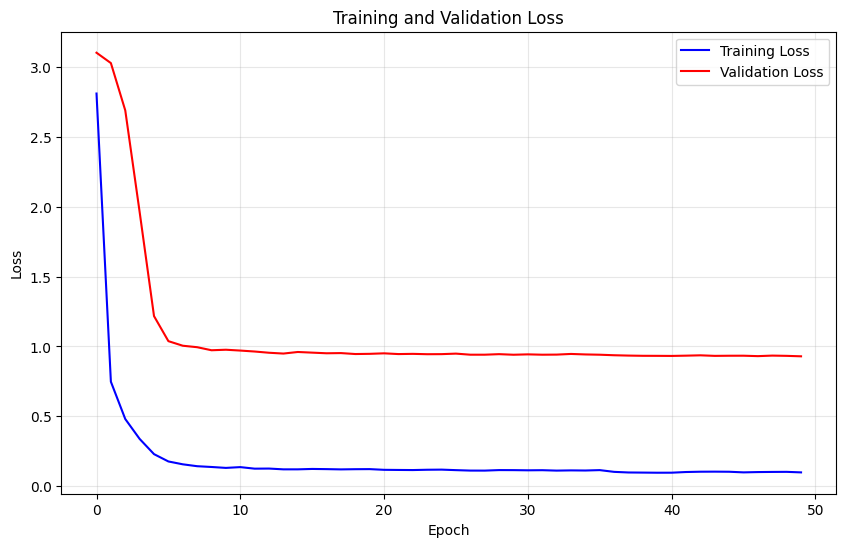

/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Evaluating model...
Training a simple MNIST classifier for evaluation...
Could not load classifier: name 'resnet18' is not defined


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 31.95it/s]

Evaluation Results:
MSE Loss: 0.9289
Visualizing results...


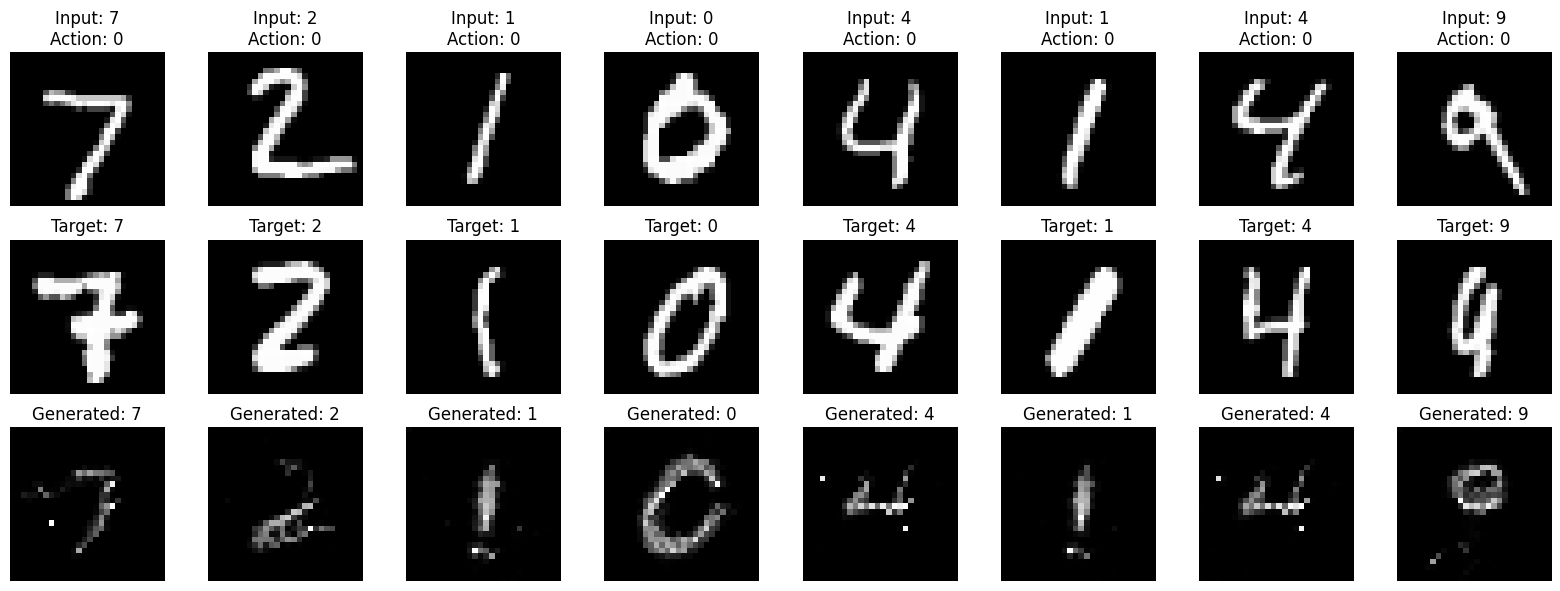

Training and evaluation complete!


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 33.30it/s]


R^2 between first PC and targets: 0.0024
Using device: cuda
Max move: 1, Action space size: 3
Training samples: 60000
Test samples: 10000
Model parameters: 4,648,247
Starting training...


Train Loss: 0.0000, Val Loss: 0.0000: 100%|█████| 50/50 [05:09<00:00,  6.19s/it]


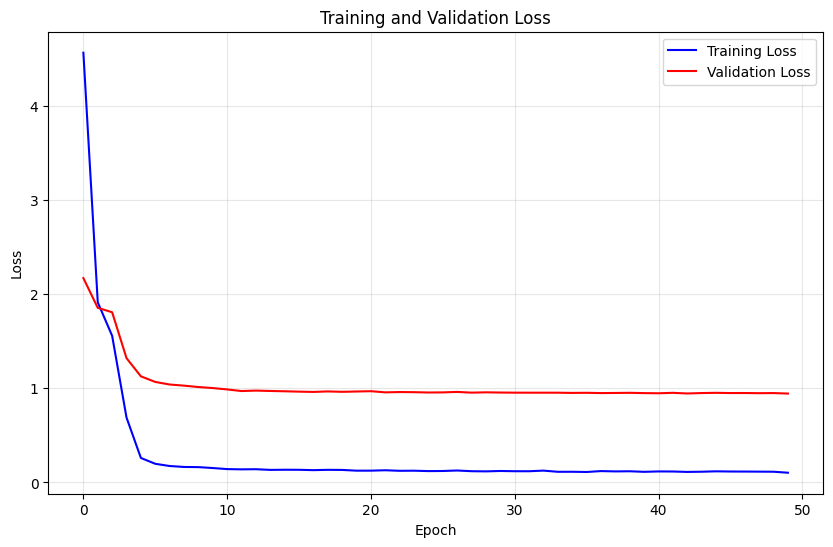

/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Evaluating model...
Training a simple MNIST classifier for evaluation...
Could not load classifier: name 'resnet18' is not defined


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 32.41it/s]

Evaluation Results:
MSE Loss: 0.9428
Visualizing results...


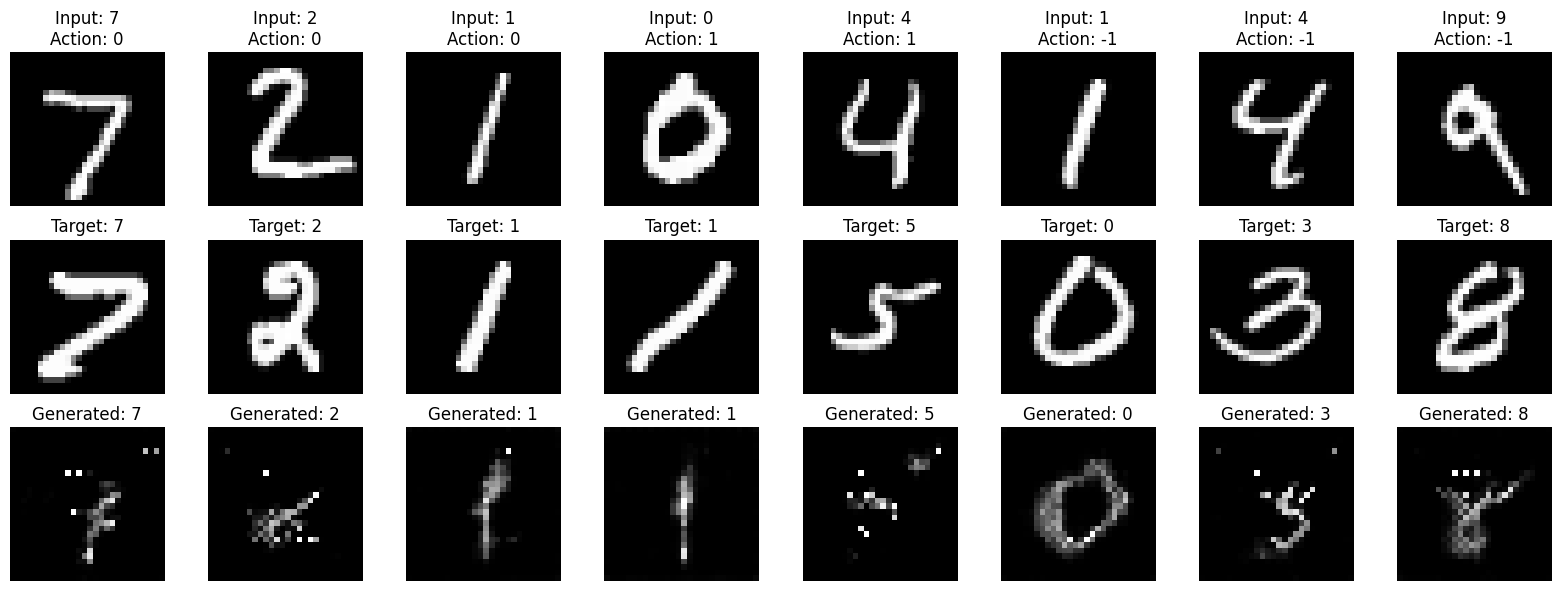

Training and evaluation complete!


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 32.56it/s]


R^2 between first PC and targets: 0.0069
Using device: cuda
Max move: 2, Action space size: 5
Training samples: 60000
Test samples: 10000
Model parameters: 4,649,249
Starting training...


Train Loss: 0.0000, Val Loss: 0.0000: 100%|█████| 50/50 [05:10<00:00,  6.21s/it]


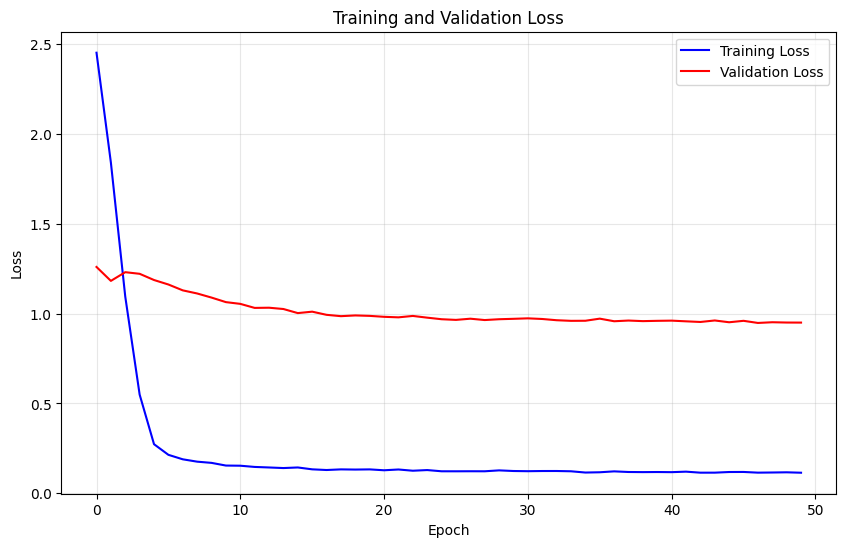

/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Evaluating model...
Training a simple MNIST classifier for evaluation...
Could not load classifier: name 'resnet18' is not defined


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 32.30it/s]

Evaluation Results:
MSE Loss: 0.9504
Visualizing results...


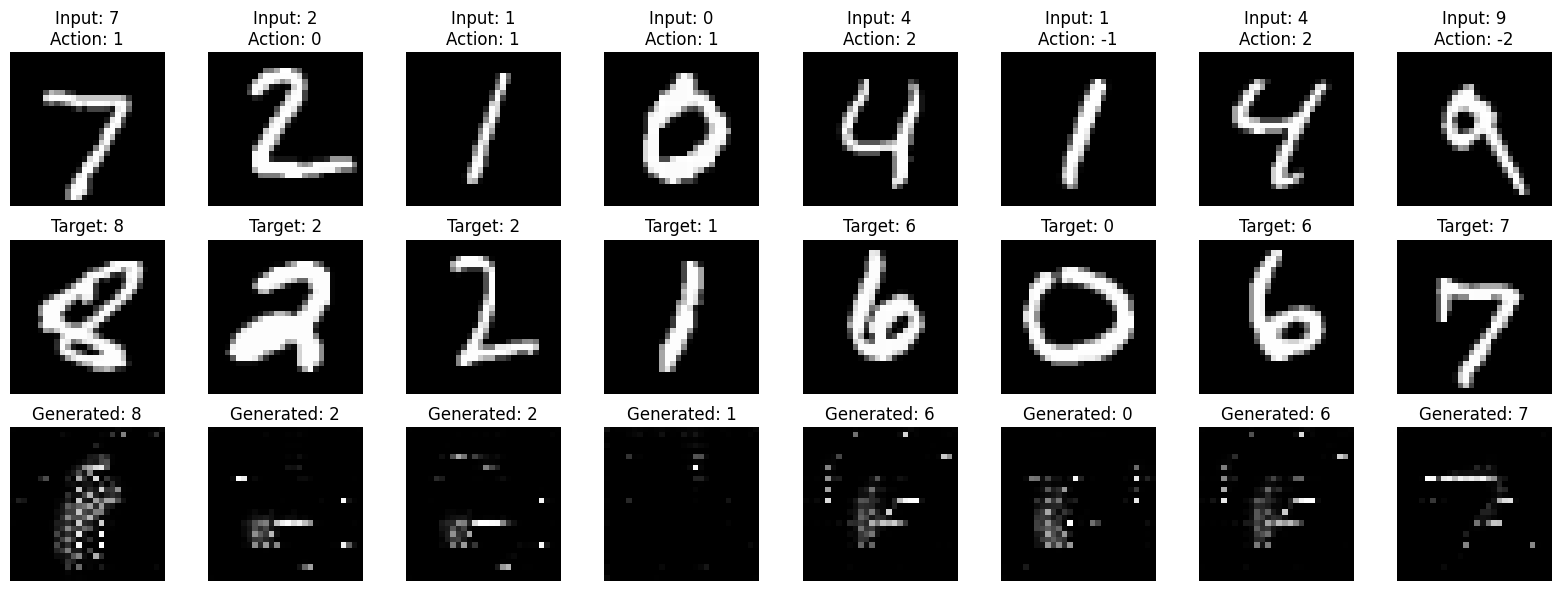

Training and evaluation complete!


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 32.49it/s]


R^2 between first PC and targets: 0.5751
Using device: cuda
Max move: 3, Action space size: 7
Training samples: 60000
Test samples: 10000
Model parameters: 4,650,251
Starting training...


Train Loss: 0.0000, Val Loss: 0.0000: 100%|█████| 50/50 [05:12<00:00,  6.25s/it]


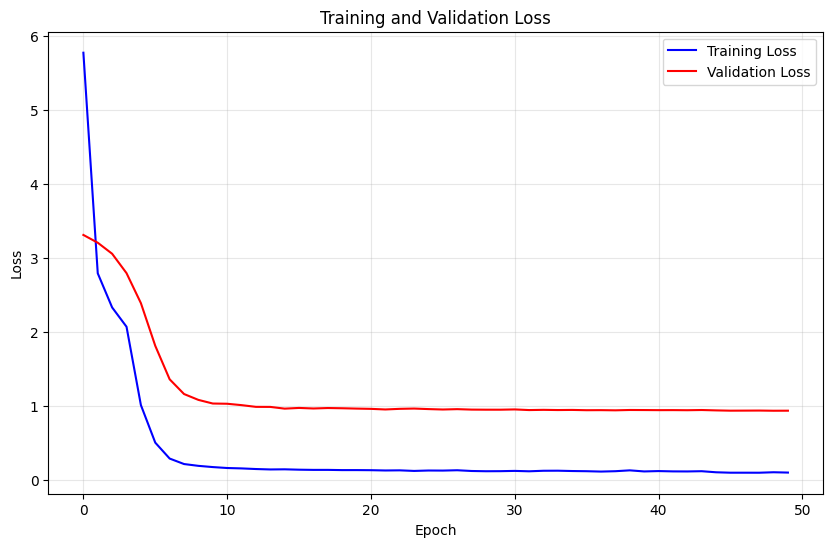

/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Evaluating model...
Training a simple MNIST classifier for evaluation...
Could not load classifier: name 'resnet18' is not defined


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 32.46it/s]

Evaluation Results:
MSE Loss: 0.9349
Visualizing results...


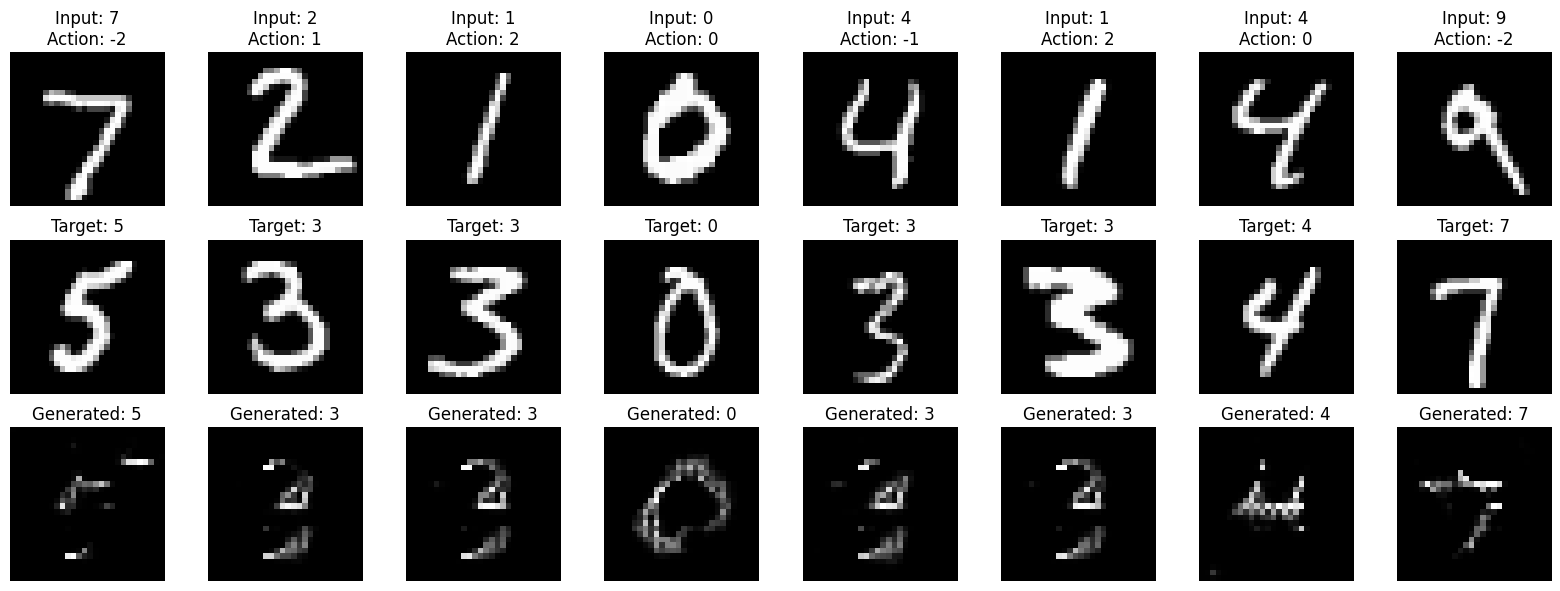

Training and evaluation complete!


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 32.48it/s]


R^2 between first PC and targets: 0.7665
Using device: cuda
Max move: 4, Action space size: 9
Training samples: 60000
Test samples: 10000
Model parameters: 4,651,253
Starting training...


Train Loss: 0.0000, Val Loss: 0.0000: 100%|█████| 50/50 [14:33<00:00, 17.48s/it]


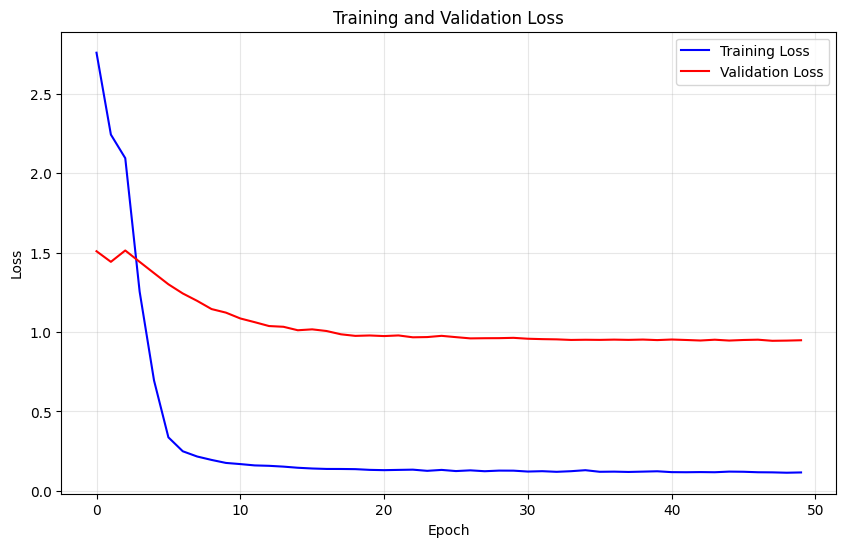

/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Evaluating model...
Training a simple MNIST classifier for evaluation...
Could not load classifier: name 'resnet18' is not defined


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 25.67it/s]

Evaluation Results:
MSE Loss: 0.9480
Visualizing results...


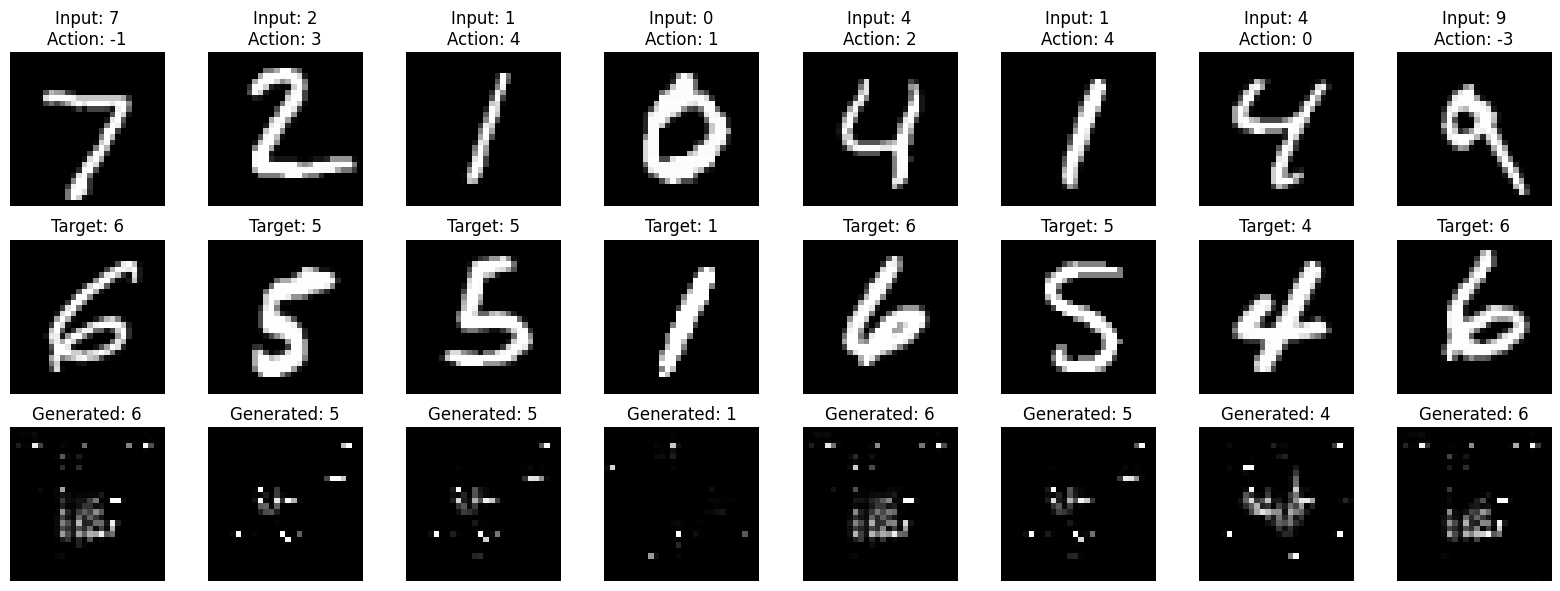

Training and evaluation complete!


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 31.31it/s]


R^2 between first PC and targets: 0.0335
Using device: cuda
Max move: 5, Action space size: 11
Training samples: 60000
Test samples: 10000
Model parameters: 4,652,255
Starting training...


Train Loss: 0.0000, Val Loss: 0.0000: 100%|█████| 50/50 [05:24<00:00,  6.49s/it]


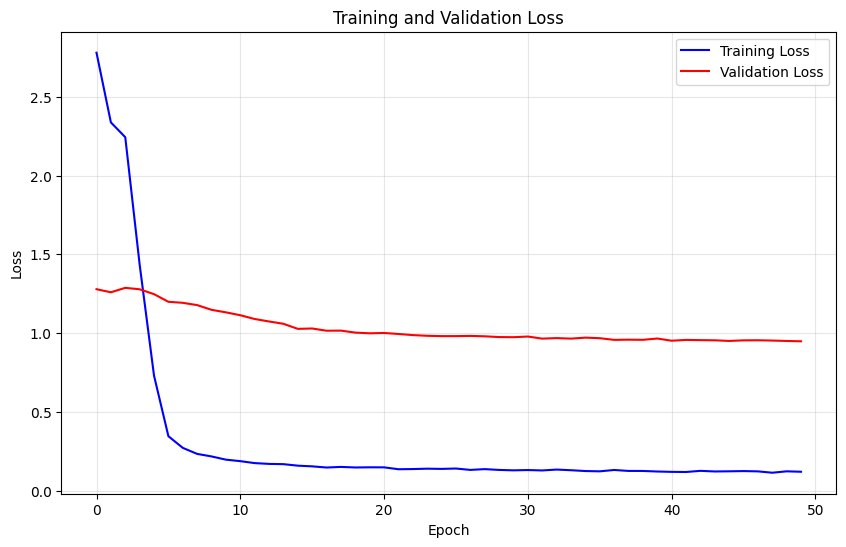

/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Evaluating model...
Training a simple MNIST classifier for evaluation...
Could not load classifier: name 'resnet18' is not defined


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 32.05it/s]

Evaluation Results:
MSE Loss: 0.9477
Visualizing results...


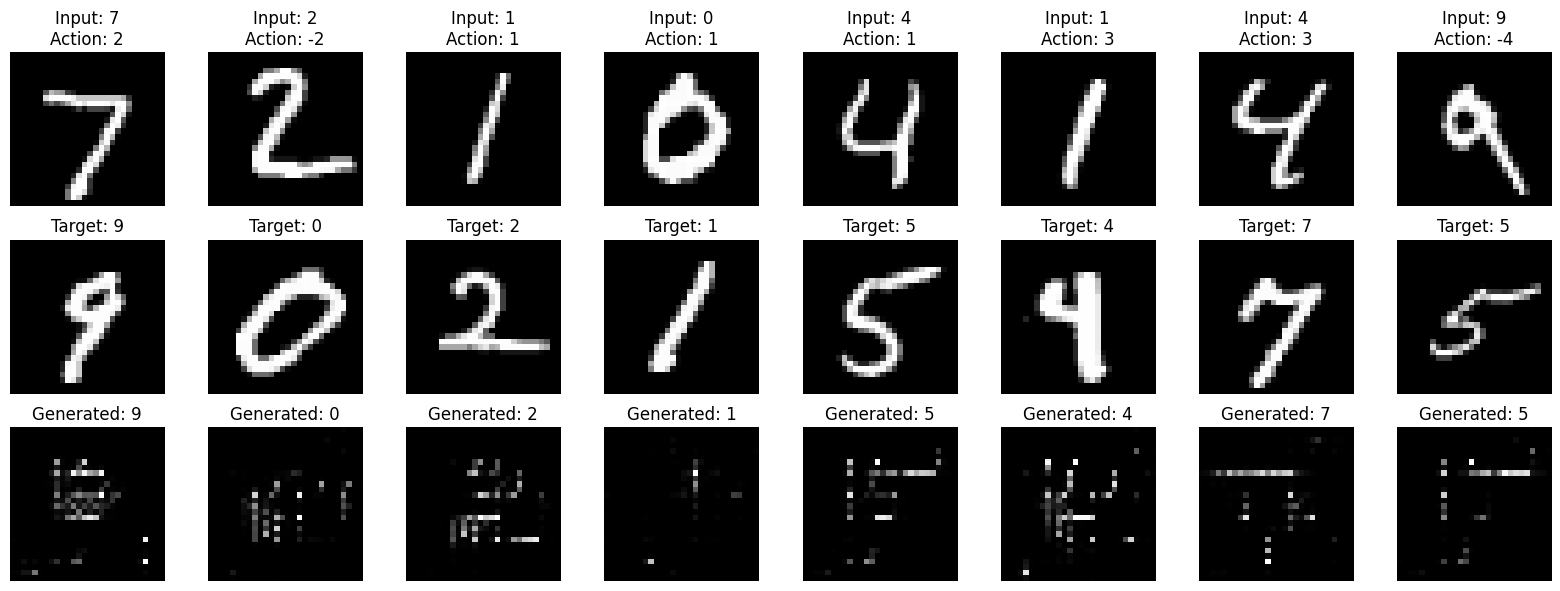

Training and evaluation complete!


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 32.14it/s]


R^2 between first PC and targets: 0.0061
Using device: cuda
Max move: 6, Action space size: 13
Training samples: 60000
Test samples: 10000
Model parameters: 4,653,257
Starting training...


Train Loss: 0.0000, Val Loss: 0.0000: 100%|█████| 50/50 [09:33<00:00, 11.48s/it]


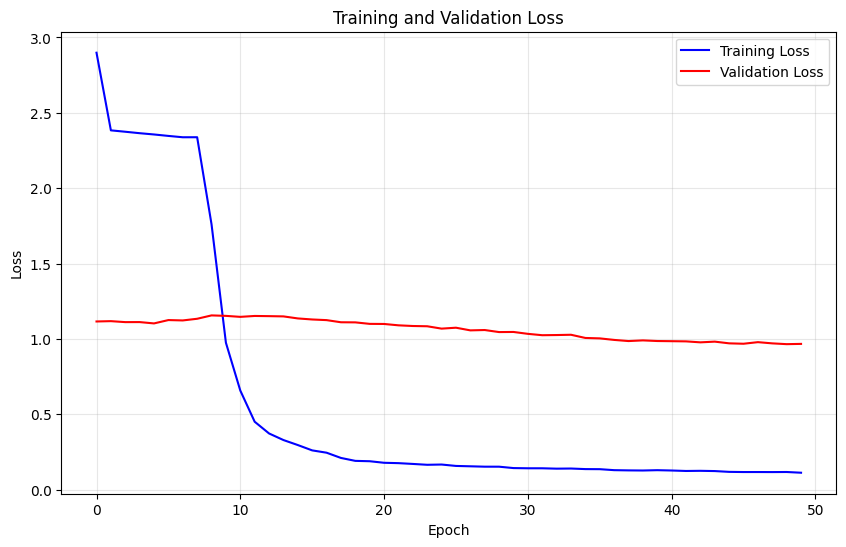

/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Evaluating model...
Training a simple MNIST classifier for evaluation...
Could not load classifier: name 'resnet18' is not defined


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 25.78it/s]

Evaluation Results:
MSE Loss: 0.9661
Visualizing results...


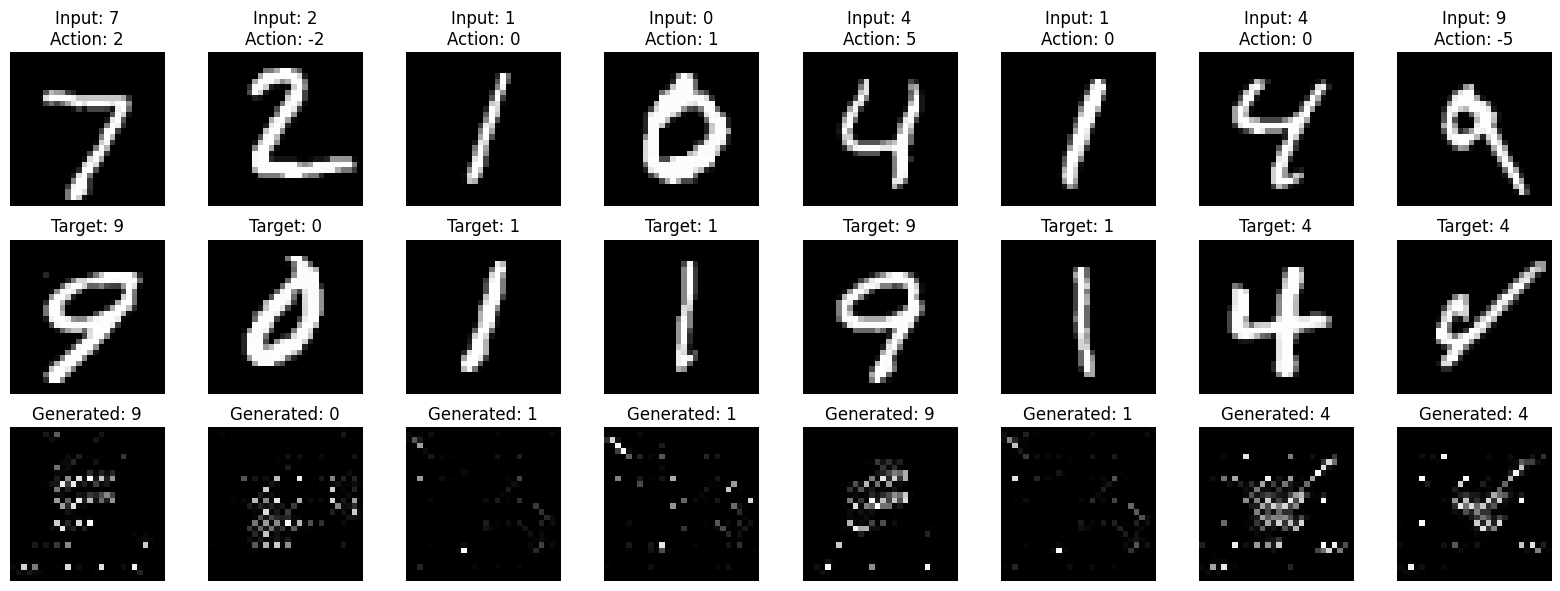

Training and evaluation complete!


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 31.34it/s]


R^2 between first PC and targets: 0.5791
Using device: cuda
Max move: 7, Action space size: 15
Training samples: 60000
Test samples: 10000
Model parameters: 4,654,259
Starting training...


Train Loss: 0.0000, Val Loss: 0.0000: 100%|█████| 50/50 [10:01<00:00, 12.03s/it]


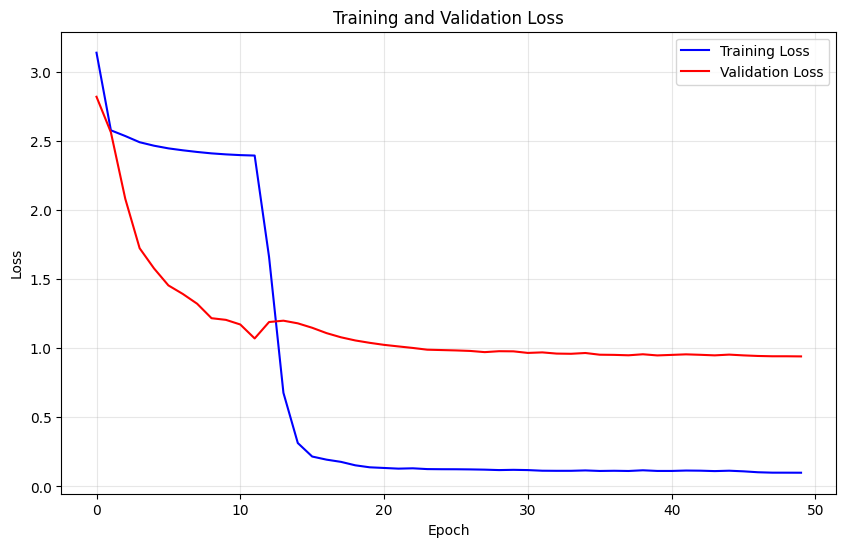

/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Evaluating model...
Training a simple MNIST classifier for evaluation...
Could not load classifier: name 'resnet18' is not defined


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 32.16it/s]

Evaluation Results:
MSE Loss: 0.9401
Visualizing results...


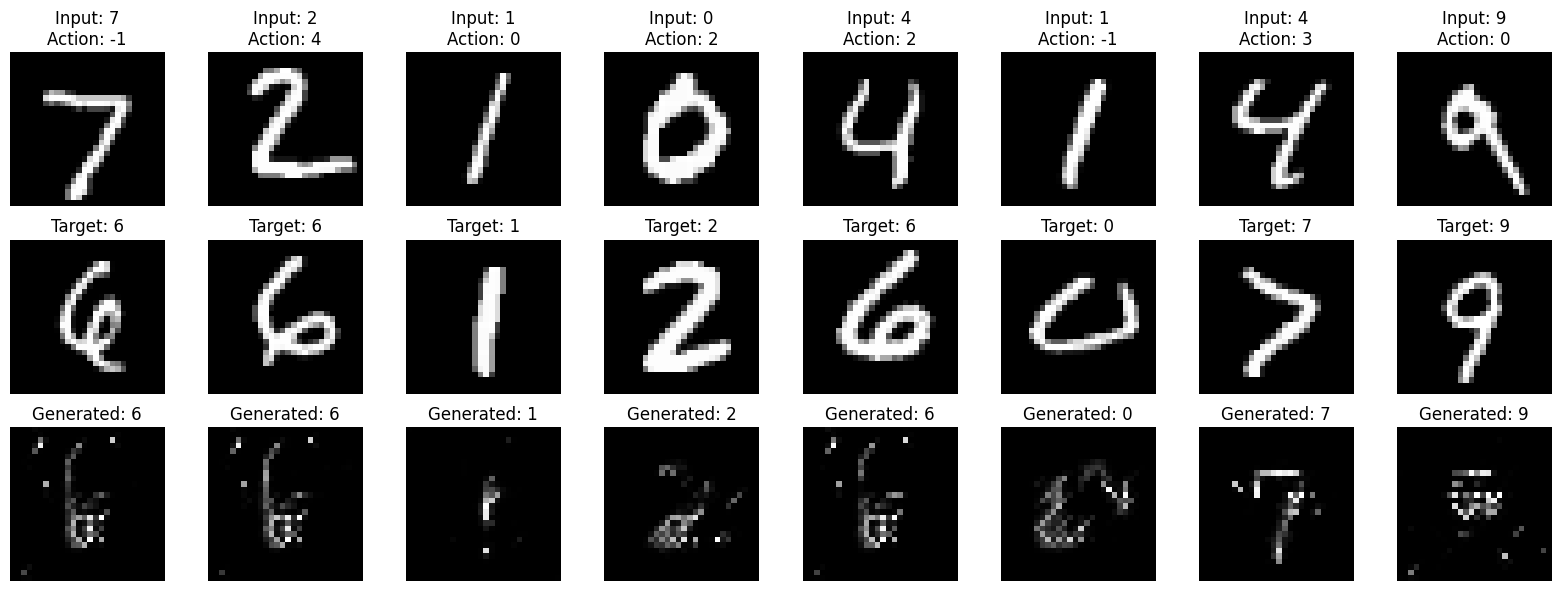

Training and evaluation complete!


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 32.20it/s]


R^2 between first PC and targets: 0.5307
Using device: cuda
Max move: 8, Action space size: 17
Training samples: 60000
Test samples: 10000
Model parameters: 4,655,261
Starting training...


Train Loss: 0.0000, Val Loss: 0.0000: 100%|█████| 50/50 [05:12<00:00,  6.25s/it]


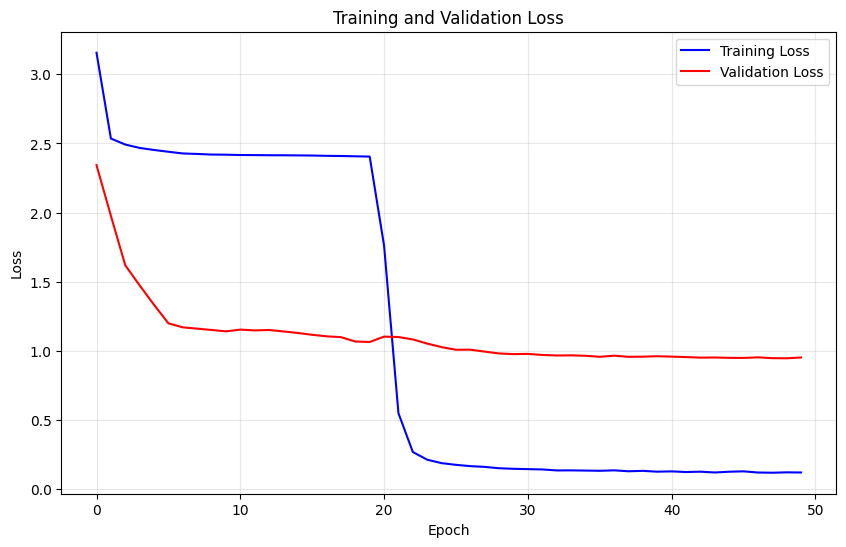

/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Evaluating model...
Training a simple MNIST classifier for evaluation...
Could not load classifier: name 'resnet18' is not defined


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 32.30it/s]

Evaluation Results:
MSE Loss: 0.9517
Visualizing results...


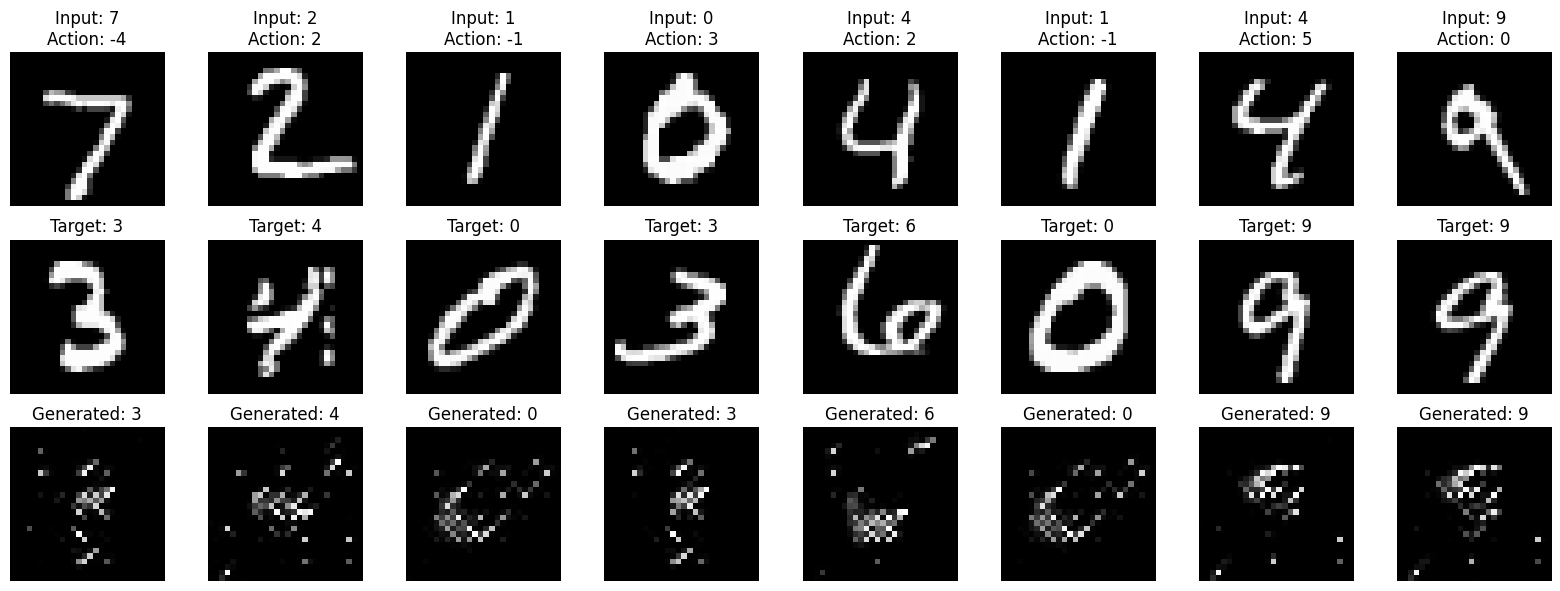

Training and evaluation complete!


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 32.16it/s]


R^2 between first PC and targets: 0.5836
Using device: cuda
Max move: 9, Action space size: 19
Training samples: 60000
Test samples: 10000
Model parameters: 4,656,263
Starting training...


Train Loss: 0.0000, Val Loss: 0.0000: 100%|█████| 50/50 [05:11<00:00,  6.22s/it]


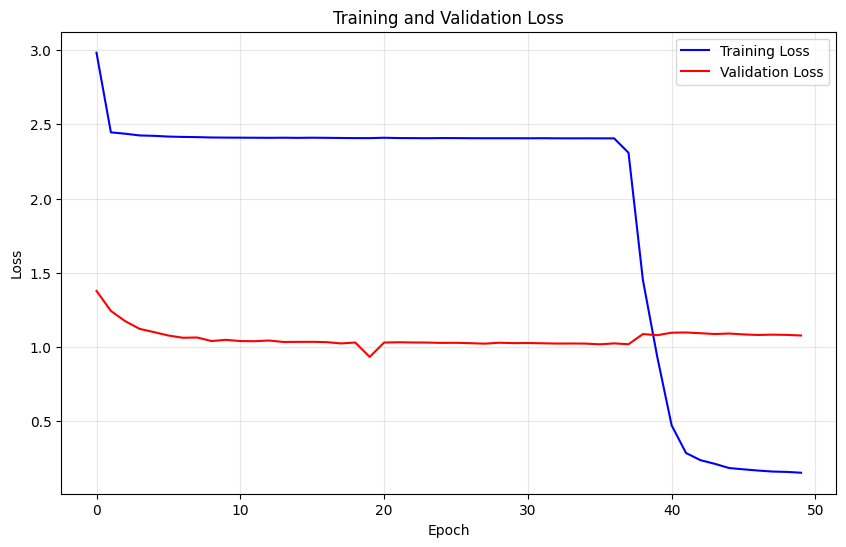

/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Evaluating model...
Training a simple MNIST classifier for evaluation...
Could not load classifier: name 'resnet18' is not defined


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 32.04it/s]

Evaluation Results:
MSE Loss: 1.0768
Visualizing results...


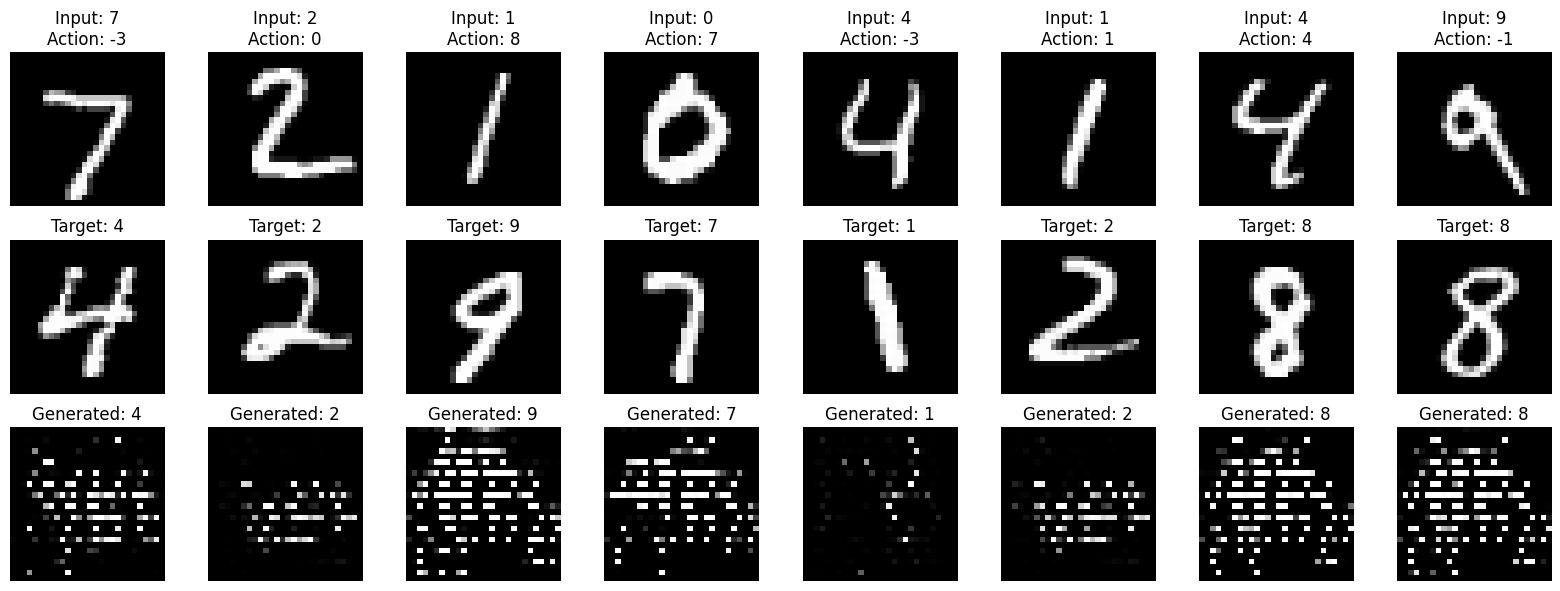

Training and evaluation complete!


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 32.20it/s]


R^2 between first PC and targets: 0.7814


In [10]:
max_move = 9
r2_l = []
NC1_l = []
for max_move in range(10):
    batch_size = 260
    lr = 0.006540	
    hidden_dim = 501
    latent_dim = 382
    epochs = 50
    n_layers_fusion = 2
    cyclic_action = False

    device = "cuda"

    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    print(f'Using device: {device}')
    print(f'Max move: {max_move}, Action space size: {2*max_move+1}')

    # Data transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
    ])

    # Load MNIST datasets
    train_mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_mnist = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    # Create custom datasets
    train_dataset = MNISTActionDataset(train_mnist, max_move=max_move, cyclic=cyclic_action)
    test_dataset = MNISTActionDataset(test_mnist, max_move=max_move, cyclic=cyclic_action)

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    print(f'Training samples: {len(train_dataset)}')
    print(f'Test samples: {len(test_dataset)}')

    # Create model
    model = MNISTActionTransformer(max_move=max_move, hidden_dim=hidden_dim, latent_dim=latent_dim, n_layers_fusion=n_layers_fusion)
    print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')

    # Split training data for validation
    train_size = int(0.8 * len(train_dataset))
    val_size = len(train_dataset) - train_size
    train_subset, val_subset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=4)

    # Train model
    print('Starting training...')
    train_losses, val_losses = train_model(
        model, train_loader, val_loader, device, 
        epochs=epochs, lr=lr, save_dir='./checkpoints'
    )

    # Plot training curves
    plot_training_curves(train_losses, val_losses)

    # Load best model
    checkpoint = torch.load('./checkpoints/best_model.pth', map_location=device, weights_only=False)
    torch.save(checkpoint, os.path.join(f'./checkpoints/best_model_max_move_{max_move}.pth'))
    model.load_state_dict(checkpoint['model_state_dict'])

    # Evaluate model
    print('Evaluating model...')
    mse_loss, accuracy = evaluate_model(model, test_loader, device, max_move)

    # Visualize results
    print('Visualizing results...')
    visualize_results(model, test_loader, device, max_move, num_samples=8)

    print('Training and evaluation complete!')


    # Collect hidden activities and target digits from the test set
    model.eval()
    hidden_acts = []
    targets = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Evaluating'):
            input_img = batch['input_img'].to(device)
            action = batch['action'].to(device)
            target_img = batch['target_img'].to(device)
            target_labels = batch['target_label'].to(device)
            
            input_img = input_img.to(device)
            action = action.to(device)
            # Forward pass to get hidden activity
            # Assuming model returns (output, hidden) or has a method to get hidden
            if hasattr(model, 'get_hidden'):
                hidden = model.get_hidden(input_img, action)
            elif hasattr(model, 'encode'):
                # If VAE-style
                hidden = model.encode(input_img, action)
                if isinstance(hidden, tuple):
                    hidden = hidden[0]
            else:
                # Try to get hidden from forward
                out = model(input_img, action)
                if isinstance(out, tuple) and len(out) > 1:
                    hidden = out[1]
                else:
                    continue  # Can't extract hidden
            hidden_acts.append(hidden.cpu().numpy())
            targets.append(target_labels.cpu().numpy())

    if len(hidden_acts) == 0:
        print("Could not extract hidden activities from the model.")
        r2 = None
        fig_name = "no_hidden_acts.png"
    else:
        hidden_acts = np.concatenate(hidden_acts, axis=0)
        targets = np.concatenate(targets, axis=0)
        # If hidden_acts is (N, 1, D), squeeze
        if len(hidden_acts.shape) == 3 and hidden_acts.shape[1] == 1:
            hidden_acts = hidden_acts[:,0,:]
        # PCA to 2D
        pca = PCA(n_components=2)
        hidden_2d = pca.fit_transform(hidden_acts)
        fig = plt.figure(figsize=(8,6))
        scatter = plt.scatter(hidden_2d[:,0], hidden_2d[:,1], c=targets, cmap='viridis', s=10, alpha=0.7)
        # Calculate the r^2 (coefficient of determination) between the first principal component and targets
        r2 = get_r_2(hidden_2d[:,:1], targets)
        print(f"R^2 between first PC and targets: {r2:.4f}")
        explained_var = pca.explained_variance_ratio_ * 100
        plt.xlabel(f'PCA 1 ({explained_var[0]:.1f}% var)')
        plt.ylabel(f'PCA 2 ({explained_var[1]:.1f}% var)')
        plt.title('2D PCA of Hidden Activity (colored by target digit)')
        plt.colorbar(scatter, ticks=range(10), label='Digit')
        plt.tight_layout()
        plt.title(f'max_move = {max_move}, r2 = {r2:.4f}')
        fig.savefig(f"figures/scan_MNIST/sweep_max_move_{max_move}.png")
        plt.close()
        r2_l.append(r2)
        NC1_l.append(calc_NC1(hidden_acts, targets))


In [12]:
max_move = 9
r2_l = []
NC1_l = []
for max_move in range(10):
    batch_size = 260
    lr = 0.006540	
    hidden_dim = 501
    latent_dim = 382
    epochs = 50
    n_layers_fusion = 2

    device = "cuda"

    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    print(f'Using device: {device}')
    print(f'Max move: {max_move}, Action space size: {2*max_move+1}')

    # Data transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
    ])

    # Load MNIST datasets
    train_mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_mnist = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    # Create custom datasets
    train_dataset = MNISTActionDataset(train_mnist, max_move=max_move, sample_max_move=0, cyclic=cyclic_action)
    test_dataset = MNISTActionDataset(test_mnist, max_move=max_move, sample_max_move=0, cyclic=cyclic_action)

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    # Create model
    model = MNISTActionTransformer(max_move=max_move, hidden_dim=hidden_dim, latent_dim=latent_dim, n_layers_fusion=n_layers_fusion).to(device)

    # Load best model
    checkpoint = torch.load(f'./checkpoints/best_model_max_move_{max_move}.pth', map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])

    # Collect hidden activities and target digits from the test set
    model.eval()
    hidden_acts = []
    targets = []
    actions = []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Evaluating'):
            input_img = batch['input_img'].to(device)
            action = batch['action'].to(device)
            target_img = batch['target_img'].to(device)
            target_labels = batch['target_label'].to(device)
            action_value = batch['action_value'].to(device)
            
            input_img = input_img.to(device)
            action = action.to(device)
            # Forward pass to get hidden activity
            # Assuming model returns (output, hidden) or has a method to get hidden
            if hasattr(model, 'get_hidden'):
                hidden = model.get_hidden(input_img, action)
            elif hasattr(model, 'encode'):
                # If VAE-style
                hidden = model.encode(input_img, action)
                if isinstance(hidden, tuple):
                    hidden = hidden[0]
            else:
                # Try to get hidden from forward
                out = model(input_img, action)
                if isinstance(out, tuple) and len(out) > 1:
                    hidden = out[1]
                else:
                    continue  # Can't extract hidden
            hidden_acts.append(hidden[abs(action_value==0)].cpu().numpy())
            targets.append(target_labels[abs(action_value==0)].cpu().numpy())

    hidden_acts = np.concatenate(hidden_acts, axis=0)
    targets = np.concatenate(targets, axis=0)
    print('Number of samples ', hidden_acts.shape[0])
    # If hidden_acts is (N, 1, D), squeeze
    if len(hidden_acts.shape) == 3 and hidden_acts.shape[1] == 1:
        hidden_acts = hidden_acts[:,0,:]
    # PCA to 2D
    pca = PCA(n_components=2)
    hidden_2d = pca.fit_transform(hidden_acts)
    fig = plt.figure(figsize=(8,6))
    scatter = plt.scatter(hidden_2d[:,0], hidden_2d[:,1], c=targets, cmap='viridis', s=10, alpha=0.7)
    # Calculate the r^2 (coefficient of determination) between the first principal component and targets
    r2 = get_r_2(hidden_2d[:,:1], targets)
    print(f"R^2 between first PC and targets: {r2:.4f}")
    explained_var = pca.explained_variance_ratio_ * 100
    plt.xlabel(f'PCA 1 ({explained_var[0]:.1f}% var)')
    plt.ylabel(f'PCA 2 ({explained_var[1]:.1f}% var)')
    plt.title('2D PCA of Hidden Activity (colored by target digit)')
    plt.colorbar(scatter, ticks=range(10), label='Digit')
    plt.tight_layout()
    plt.title(f'max_move = {max_move}, r2 = {r2:.4f}')
    fig.savefig(f"figures/scan_MNIST/sweep_max_move_{max_move}.png")
    plt.close()
    r2_l.append(r2)
    NC1_l.append(calc_NC1(hidden_acts, targets))


Using device: cuda
Max move: 0, Action space size: 1


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 27.66it/s]


Number of samples  10000
R^2 between first PC and targets: 0.0024
Using device: cuda
Max move: 1, Action space size: 3


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 29.23it/s]


Number of samples  10000
R^2 between first PC and targets: 0.0232
Using device: cuda
Max move: 2, Action space size: 5


...

Number of samples  10000
R^2 between first PC and targets: 0.4796
Using device: cuda
Max move: 8, Action space size: 17


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 29.79it/s]


Number of samples  10000
R^2 between first PC and targets: 0.4902
Using device: cuda
Max move: 9, Action space size: 19


Evaluating: 100%|███████████████████████████████| 39/39 [00:01<00:00, 29.31it/s]


Number of samples  10000
R^2 between first PC and targets: 0.8026


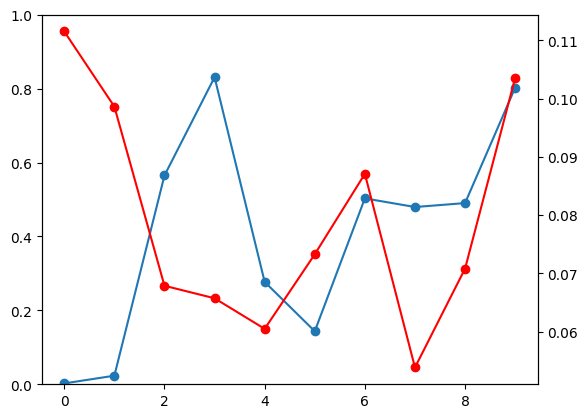

In [13]:
plt.plot(r2_l, marker='o')
plt.ylim(0, 1)
plt.gca().twinx().plot(NC1_l, c='r', marker='o')
plt.show()

Using device: cuda
Max move: 4, Action space size: 9


Evaluating: 100%|███████████████████████████████| 33/33 [00:01<00:00, 23.27it/s]


Number of samples  10000
R^2 between first PC and targets: 0.9024


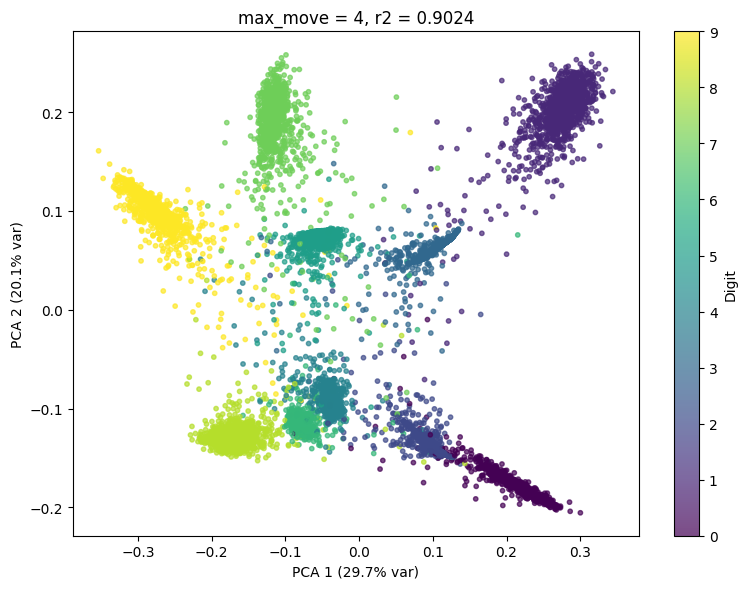

In [ ]:
max_move = np.argmax(r2_l)
device = "cuda"

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print(f'Using device: {device}')
print(f'Max move: {max_move}, Action space size: {2*max_move+1}')

# Data transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# Load MNIST datasets
train_mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_mnist = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create custom datasets
train_dataset = MNISTActionDataset(train_mnist, max_move=max_move, sample_max_move=0, cyclic=cyclic_action)
test_dataset = MNISTActionDataset(test_mnist, max_move=max_move, sample_max_move=0, cyclic=cyclic_action)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

# Create model
model = MNISTActionTransformer(max_move=max_move, hidden_dim=hidden_dim, latent_dim=latent_dim, n_layers_fusion=n_layers_fusion).to(device)

# Load best model
checkpoint = torch.load(f'./checkpoints/best_model_max_move_{max_move}.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

# Collect hidden activities and target digits from the test set
model.eval()
hidden_acts = []
targets = []
actions = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Evaluating'):
        input_img = batch['input_img'].to(device)
        action = batch['action'].to(device)
        target_img = batch['target_img'].to(device)
        target_labels = batch['target_label'].to(device)
        action_value = batch['action_value'].to(device)
        
        input_img = input_img.to(device)
        action = action.to(device)
        # Forward pass to get hidden activity
        # Assuming model returns (output, hidden) or has a method to get hidden
        if hasattr(model, 'get_hidden'):
            hidden = model.get_hidden(input_img, action)
        elif hasattr(model, 'encode'):
            # If VAE-style
            hidden = model.encode(input_img, action)
            if isinstance(hidden, tuple):
                hidden = hidden[0]
        else:
            # Try to get hidden from forward
            out = model(input_img, action)
            if isinstance(out, tuple) and len(out) > 1:
                hidden = out[1]
            else:
                continue  # Can't extract hidden
        hidden_acts.append(hidden[abs(action_value==0)].cpu().numpy())
        targets.append(target_labels[abs(action_value==0)].cpu().numpy())

hidden_acts = np.concatenate(hidden_acts, axis=0)
targets = np.concatenate(targets, axis=0)
print('Number of samples ', hidden_acts.shape[0])
# If hidden_acts is (N, 1, D), squeeze
if len(hidden_acts.shape) == 3 and hidden_acts.shape[1] == 1:
    hidden_acts = hidden_acts[:,0,:]
# PCA to 2D
pca = PCA(n_components=2)
hidden_2d = pca.fit_transform(hidden_acts)
fig = plt.figure(figsize=(8,6))
scatter = plt.scatter(hidden_2d[:,0], hidden_2d[:,1], c=targets, cmap='viridis', s=10, alpha=0.7)
# Calculate the r^2 (coefficient of determination) between the first principal component and targets
r2 = get_r_2(hidden_2d[:,:1], targets)
print(f"R^2 between first PC and targets: {r2:.4f}")
explained_var = pca.explained_variance_ratio_ * 100
plt.xlabel(f'PCA 1 ({explained_var[0]:.1f}% var)')
plt.ylabel(f'PCA 2 ({explained_var[1]:.1f}% var)')
plt.title('2D PCA of Hidden Activity (colored by target digit)')
plt.colorbar(scatter, ticks=range(10), label='Digit')
plt.tight_layout()
plt.title(f'max_move = {max_move}, r2 = {r2:.4f}')
fig.savefig(f"figures/scan_MNIST/sweep_max_move_{max_move}.png")
plt.show()

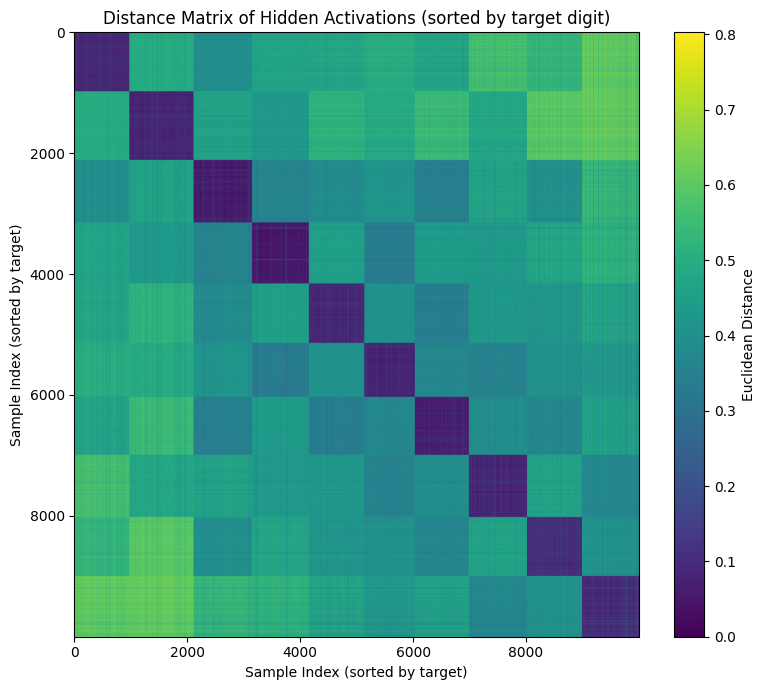

In [ ]:
# Compute pairwise distance matrix of hidden activations, sorted by targets
from scipy.spatial.distance import pdist, squareform

# Sort hidden_acts and targets by targets
sort_idx = np.argsort(targets)
hidden_sorted = hidden_acts[sort_idx]
targets_sorted = targets[sort_idx]

# Compute pairwise Euclidean distances
dist_matrix = squareform(pdist(hidden_sorted, metric='euclidean'))

plt.figure(figsize=(8, 7))
plt.imshow(dist_matrix, aspect='auto', cmap='viridis')
plt.colorbar(label='Euclidean Distance')
plt.title('Distance Matrix of Hidden Activations (sorted by target digit)')
plt.xlabel('Sample Index (sorted by target)')
plt.ylabel('Sample Index (sorted by target)')
# Optionally, add lines to show digit boundaries
unique_targets, counts = np.unique(targets_sorted, return_counts=True)
boundaries = np.cumsum(counts)
# for b in boundaries[:-1]:
#     plt.axhline(b-0.5, color='white', linestyle='--', linewidth=0.5)
#     plt.axvline(b-0.5, color='white', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


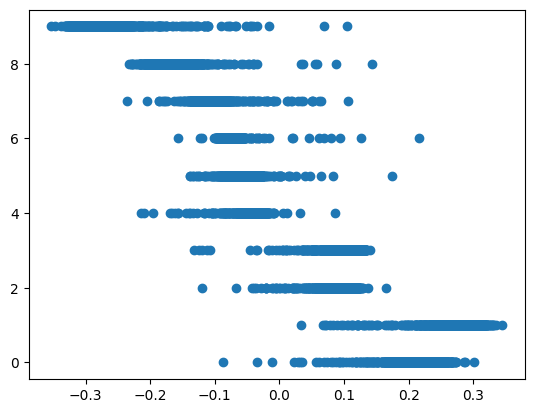

In [ ]:
plt.scatter(hidden_2d[:,0], targets)

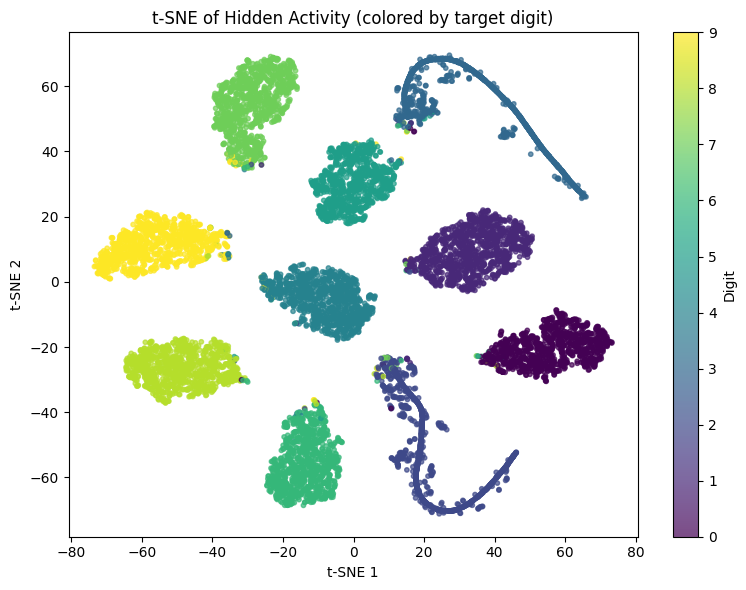

/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


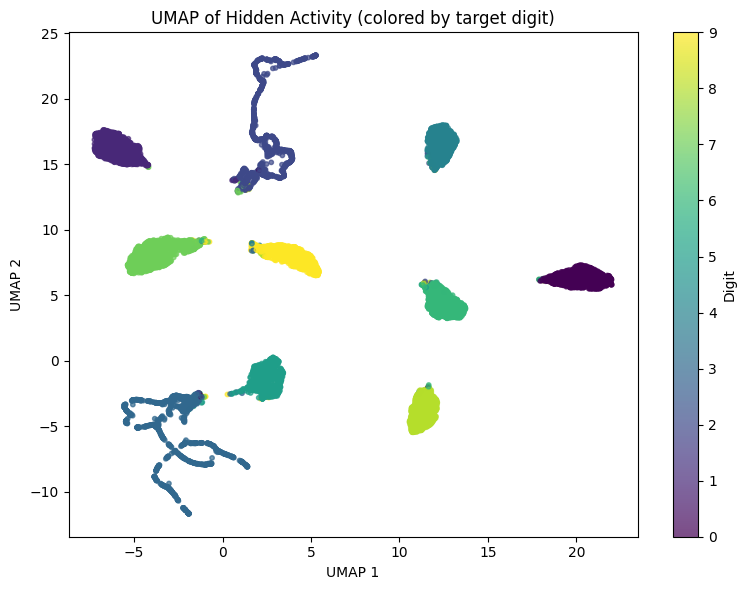

In [ ]:
# Plot t-SNE of hidden_acts
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto', perplexity=50)
hidden_tsne = tsne.fit_transform(hidden_acts)
plt.figure(figsize=(8,6))
scatter = plt.scatter(hidden_tsne[:,0], hidden_tsne[:,1], c=targets, cmap='viridis', s=10, alpha=0.7)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE of Hidden Activity (colored by target digit)')
plt.colorbar(scatter, ticks=range(10), label='Digit')
plt.tight_layout()
plt.show()

# Plot UMAP of hidden_acts
try:
    import umap
except ImportError:
    import umap.umap_ as umap

umap_model = umap.UMAP(n_components=2, random_state=42)
hidden_umap = umap_model.fit_transform(hidden_acts)
plt.figure(figsize=(8,6))
scatter = plt.scatter(hidden_umap[:,0], hidden_umap[:,1], c=targets, cmap='viridis', s=10, alpha=0.7)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP of Hidden Activity (colored by target digit)')
plt.colorbar(scatter, ticks=range(10), label='Digit')
plt.tight_layout()
plt.show()
